In [1]:
%matplotlib inline


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sea

In [5]:
developers = pd.read_csv("https://docs.google.com/spreadsheets/d/1bclX5PbqE8zR1-wOSM3ZTFa53sIC7RXqwty7Abmw9yQ/export?format=csv&gid=1724592523")
print(developers.head())

   N                    Посада Мова програмування Спеціалізація  \
0  1        Junior QA engineer                NaN     Manual QA   
1  2        Junior QA engineer                NaN     Manual QA   
2  3         Software Engineer            C#/.NET           NaN   
3  4         Software Engineer         JavaScript           NaN   
4  5  Senior Software Engineer         JavaScript           NaN   

  Загальний досвід роботи Досвід роботи на поточному місці  \
0                     0.5                              0.5   
1         менше 3 місяців                  менше 3 місяців   
2                       4                                1   
3                       5                                4   
4       10 і більше років                              0.5   

   Зарплата на місяць  Зміна зарплати за 12 місяців   Місто   Розмір компанії  \
0                 400                             0  Харків        до 10 осіб   
1                 430                           130  Харків  б

## Розмір

In [6]:
print(developers.shape)

(8704, 25)


## Типи стовпців

In [7]:
print(developers.dtypes)

N                                     int64
Посада                               object
Мова програмування                   object
Спеціалізація                        object
Загальний досвід роботи              object
Досвід роботи на поточному місці     object
Зарплата на місяць                    int64
Зміна зарплати за 12 місяців          int64
Місто                                object
Розмір компанії                      object
Тип компанії                         object
Стать                                object
Вік                                   int64
Освіта                               object
Університет                          object
Ще студент                             bool
Рівень англійської                   object
Предметна область                    object
Дата заповнення                      object
User.Agent                           object
exp                                 float64
current_job_exp                     float64
salary                          

## Частка пропусків

In [8]:
all_nan = developers.isnull().sum()
fraction = all_nan / developers.shape[0]
print(fraction)

N                                   0.000000
Посада                              0.000000
Мова програмування                  0.442325
Спеціалізація                       0.829389
Загальний досвід роботи             0.000000
Досвід роботи на поточному місці    0.000000
Зарплата на місяць                  0.000000
Зміна зарплати за 12 місяців        0.000000
Місто                               0.000000
Розмір компанії                     0.000000
Тип компанії                        0.000000
Стать                               0.000000
Вік                                 0.000000
Освіта                              0.000000
Університет                         0.041131
Ще студент                          0.000000
Рівень англійської                  0.000000
Предметна область                   0.025620
Дата заповнення                     0.000000
User.Agent                          0.000000
exp                                 0.000000
current_job_exp                     0.000000
salary    

## Видалення стовпців корім мови програмування

In [9]:
developers = developers.drop(developers.columns[
    (developers.isnull().sum() > 0) &
    (developers.columns != "Мова програмування")
], axis = 1)
print(developers.head(3))

   N              Посада Мова програмування Загальний досвід роботи  \
0  1  Junior QA engineer                NaN                     0.5   
1  2  Junior QA engineer                NaN         менше 3 місяців   
2  3   Software Engineer            C#/.NET                       4   

  Досвід роботи на поточному місці  Зарплата на місяць  \
0                              0.5                 400   
1                  менше 3 місяців                 430   
2                                1                2500   

   Зміна зарплати за 12 місяців   Місто   Розмір компанії   Тип компанії  \
0                             0  Харків        до 10 осіб  Аутсорсингова   
1                           130  Харків  більше 1000 осіб  Аутсорсингова   
2                           800    Київ      до 1000 осіб  Аутсорсингова   

      Стать  Вік        Освіта  Ще студент  \
0    жіноча   20  Неповна Вища        True   
1    жіноча   21  Неповна Вища        True   
2  чоловіча   26          Вища       Fa

## Частка пропусків 2

In [10]:
nan = developers.isnull().sum()
result = nan / developers.shape[0]
print(result)

N                                   0.000000
Посада                              0.000000
Мова програмування                  0.442325
Загальний досвід роботи             0.000000
Досвід роботи на поточному місці    0.000000
Зарплата на місяць                  0.000000
Зміна зарплати за 12 місяців        0.000000
Місто                               0.000000
Розмір компанії                     0.000000
Тип компанії                        0.000000
Стать                               0.000000
Вік                                 0.000000
Освіта                              0.000000
Ще студент                          0.000000
Рівень англійської                  0.000000
Дата заповнення                     0.000000
User.Agent                          0.000000
exp                                 0.000000
current_job_exp                     0.000000
salary                              0.000000
dtype: float64


## Dropna і новий розмір таблиці

In [11]:
developers = developers.dropna()
print(developers.shape)

(4854, 20)


## Таблиця python розробників та розмір

In [13]:
python_data = developers[
    developers["Мова програмування"] == "Python"
]
print(python_data)
print(python_data.shape)

         N                    Посада Мова програмування  \
12      13         Software Engineer             Python   
68      69         Software Engineer             Python   
87      88  Junior Software Engineer             Python   
114    115  Junior Software Engineer             Python   
143    144  Junior Software Engineer             Python   
...    ...                       ...                ...   
8546  8547         Software Engineer             Python   
8625  8626         Software Engineer             Python   
8635  8636  Senior Software Engineer             Python   
8673  8674  Junior Software Engineer             Python   
8695  8696         Software Engineer             Python   

     Загальний досвід роботи Досвід роботи на поточному місці  \
12                         1                  менше 3 місяців   
68                       1.5                              0.5   
87                       0.5                              0.5   
114                      1.5   

## Групування та агрегація

In [16]:
post = python_data.groupby("Посада")
salary_per_month = post["Зарплата на місяць"].agg(["min", "max"])
print(salary_per_month)

                           min   max
Посада                              
Junior Software Engineer   100  1250
Senior Software Engineer  1300  9200
Software Engineer          500  5400
System Architect          3000  5000
Technical Lead            1425  6200


## Застосування функції до груп

In [20]:
def fill_avg_salary(group):
    return group["Зарплата на місяць"].mean()

In [22]:
salary_per_month["avg"] = post.apply(fill_avg_salary)
print(salary_per_month)

                           min   max          avg
Посада                                           
Junior Software Engineer   100  1250   560.841270
Senior Software Engineer  1300  9200  3387.096774
Software Engineer          500  5400  1799.070000
System Architect          3000  5000  4000.000000
Technical Lead            1425  6200  3165.909091


/var/folders/l1/p8rl2c017cl1c3z_w34shb3w0000gn/T/ipykernel_98901/1045477707.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  salary_per_month["avg"] = post.apply(fill_avg_salary)


## Описова статистика

In [24]:
print(salary_per_month["avg"].describe())

count       5.000000
mean     2582.583427
std      1387.255829
min       560.841270
25%      1799.070000
50%      3165.909091
75%      3387.096774
max      4000.000000
Name: avg, dtype: float64


## Збереження у csv

In [25]:
salary_per_month.to_csv("salarys.csv")

## Візуалізація

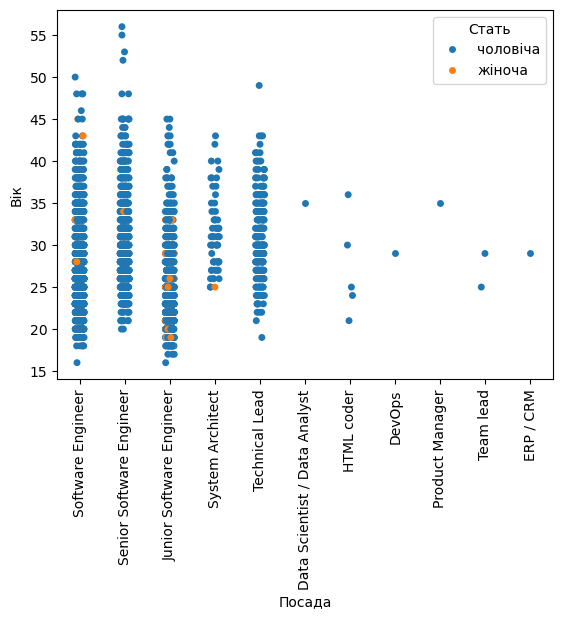

In [31]:
sns.stripplot(x="Посада", y="Вік", hue="Стать", data=developers)
plt.xticks(rotation=90)
plt.show()

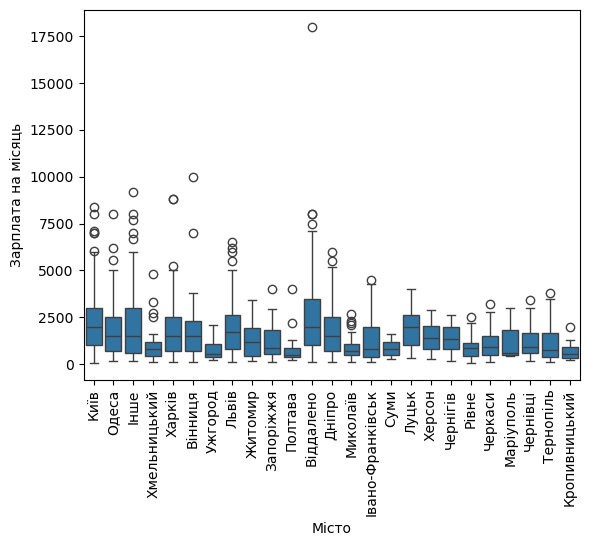

In [34]:
sns.boxplot(
    x="Місто",
    y="Зарплата на місяць",
    data=developers
)
plt.xticks(rotation=90)
plt.show()

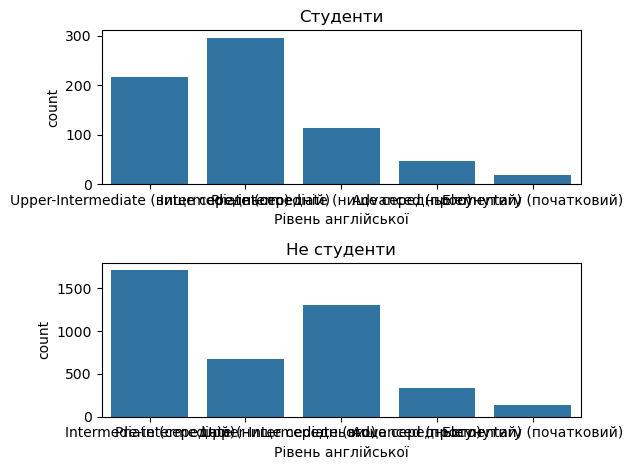

In [39]:
students = developers[developers["Ще студент"] == True]
not_students = developers[developers["Ще студент"] == False]
fig, axs = plt.subplots(2, 1)

sns.countplot(
    x="Рівень англійської",
    data=students,
    ax=axs[0]
)

sns.countplot(
    x="Рівень англійської",
    data=not_students,
    ax=axs[1]
)

axs[0].set_title("Студенти")
axs[1].set_title("Не студенти")

plt.tight_layout()

plt.show()